In [13]:
# pillow hanya untuk import image saja
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [24]:
image = Image.open("sizune.jpg").convert("L")  # Convert to grayscale
image_array = np.array(image, dtype=np.float32)


In [15]:
def finite_difference(image_array, type='forward'):
    output_x = np.zeros_like(image_array)
    output_y = np.zeros_like(image_array)

    if type == 'forward':
        output_y[:-1, :] = image_array[1:, :] - image_array[:-1, :]  # forward difference in Y direction (axis 0)
        output_x[:, :-1] = image_array[:, 1:] - image_array[:, :-1]  # forward difference in X direction (axis 1)

    elif type == "backward":
        output_y[1:, :] = image_array[1:, :] - image_array[:-1, :]   # backward difference in Y direction (axis 0)
        output_x[:, 1:] = image_array[:, 1:] - image_array[:, :-1]   # backward difference in X direction (axis 1)

    elif type == "central":
        output_y[1:-1, :] = (image_array[2:, :] - image_array[:-2, :]) / 2   # central difference in Y direction (axis 0)
        output_x[:, 1:-1] = (image_array[:, 2:] - image_array[:, :-2]) / 2   # central difference in X direction (axis 1)

    return output_x, output_y

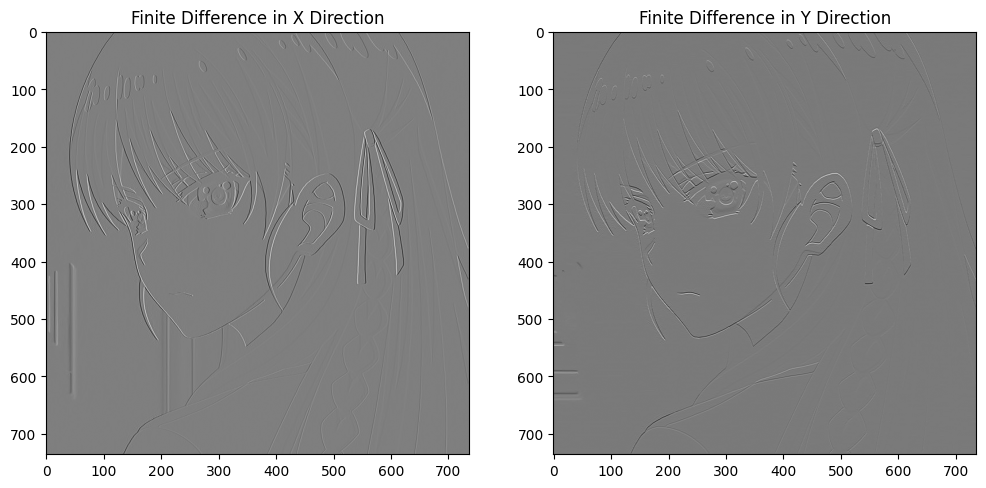

In [25]:
dx,dy = finite_difference(image_array, type='forward')
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Finite Difference in X Direction")
plt.imshow(dx, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Finite Difference in Y Direction")
plt.imshow(dy, cmap='gray')
plt.show()

In [18]:
def apply_kernel(image_array,type_kernel):
    """fungsi untuk menerapkan kernel pada gambar menggunakan konvolusi manual"""
    
    # pilih kernel berdasarkan jenis yang diinginkan
    if type_kernel == "sobel":
        kernel_x = np.array([[ -1, 0, 1],
                             [ -2, 0, 2],
                             [ -1, 0, 1]])
        kernel_y = np.array([[ 1, 2, 1],
                             [ 0, 0, 0],
                             [-1,-2,-1]])
    elif type_kernel == "prewitt":
        kernel_x = np.array([[ -1, 0, 1],
                             [ -1, 0, 1],
                             [ -1, 0, 1]])
        kernel_y = np.array([[ 1, 1, 1],
                             [ 0, 0, 0],
                             [-1,-1,-1]])
    else:
        raise ValueError("Invalid kernel type. Use 'sobel' or 'prewitt'.")
    
    
    
    # output untuk menyimpan hasil konvolusi
    output_x = np.zeros_like(image_array)
    output_y = np.zeros_like(image_array)
    
    # pad image dengan 0 di sekelilingnya untuk menghindari masalah indeks saat konvolusi
    image_padded = np.pad(image_array, ((1, 1), (1, 1)), mode='constant', constant_values=0)
    
    # lakukan konvolusi dengan kernel
    for i in range(1, image_padded.shape[0] - 1):
        for j in range(1, image_padded.shape[1] - 1):
            region = image_padded[i-1:i+2, j-1:j+2]
            output_x[i-1, j-1] = np.sum(region * kernel_x)
            output_y[i-1, j-1] = np.sum(region * kernel_y)
            
    return output_x, output_y
    

In [19]:
def magnitude_and_direction(dx,dy):
    magnitude = np.sqrt(dx**2 + dy**2)
    direction = np.arctan2(dy, dx)
    
    normalized = (magnitude / magnitude.max()) * 255
    
    return normalized, direction

# apply the function

In [28]:
def edge_detection(image_array, type_kernel):
    dx, dy = apply_kernel(image_array, type_kernel)
    magnitude, direction = magnitude_and_direction(dx, dy)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title(f"{type_kernel.capitalize()} Edge Magnitude")
    plt.imshow(magnitude, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title(f"{type_kernel.capitalize()} Edge Direction")
    plt.imshow(direction, cmap='hsv')
    plt.colorbar(label='Direction (radians)')
    plt.show()
    
    return magnitude, direction


# Sobel Edge Detection

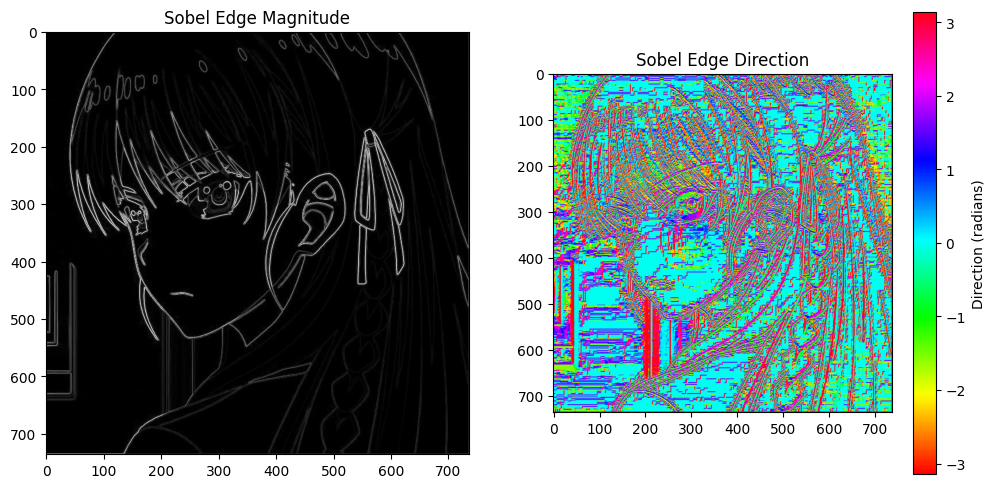

In [29]:
magSobel, dirSobel = edge_detection(image_array, type_kernel="sobel")

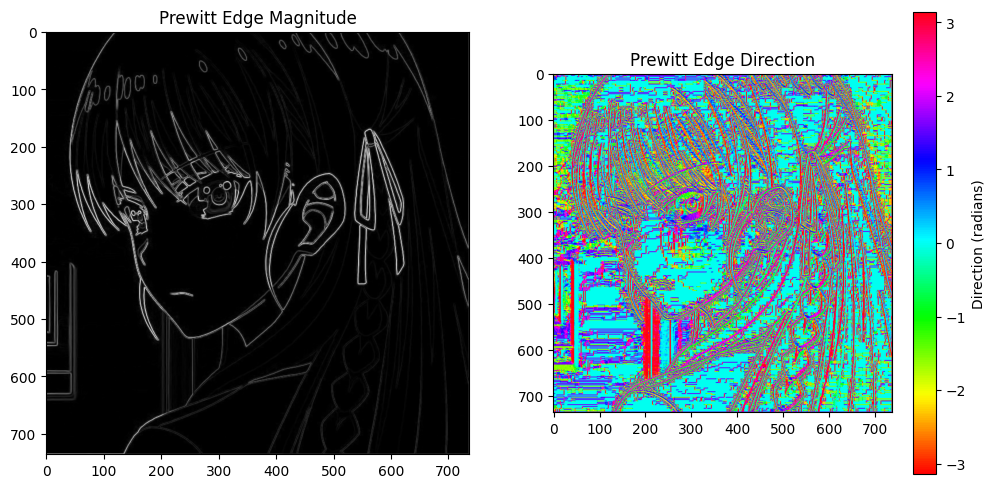

In [30]:
magPrewitt, dirPrewitt = edge_detection(image_array, type_kernel="prewitt")

In [32]:
print("Sobel Magnitude:\n", magSobel)
print("Sobel Direction:\n", dirSobel)


Sobel Magnitude:
 [[161.0787    150.18385   149.70792   ...  58.6299     58.6299
   62.186398 ]
 [150.13579     9.659396    8.495409  ...   0.          0.
   58.6299   ]
 [145.95856     6.97245     6.247448  ...   0.          0.
   58.6299   ]
 ...
 [158.35335     1.4010988   1.7327304 ...   0.          0.
   53.82417  ]
 [158.83101     1.3592656   1.7327304 ...   0.          0.
   53.82417  ]
 [168.88875   158.83101   158.35335   ...  53.82417    53.82417
   57.08915  ]]
Sobel Direction:
 [[-0.77695954 -1.5787961  -1.5820318  ... -1.5707964  -1.5707964
  -2.3561945 ]
 [ 0.05123717  1.670465    1.7126933  ...  0.          0.
   3.1415927 ]
 [ 0.03787315  1.6052654   1.5707964  ...  0.          0.
   3.1415927 ]
 ...
 [-0.00758711 -2.1112158  -2.55359    ...  0.          0.
   3.1415927 ]
 [-0.00453855 -2.3561945  -2.55359    ...  0.          0.
   3.1415927 ]
 [ 0.7853982   1.5753349   1.5783834  ...  1.5707964   1.5707964
   2.3561945 ]]


In [33]:
print("Prewitt Magnitude:\n", magPrewitt)
print("Prewitt Direction:\n", dirPrewitt)

Prewitt Magnitude:
 [[147.86108   155.66872   155.00739   ...  60.739426   60.739426
   57.265682 ]
 [155.48991    10.006947    8.731174  ...   0.          0.
   60.739426 ]
 [151.43256     7.3095465   6.306279  ...   0.          0.
   60.739426 ]
 ...
 [163.96628     1.4843441   1.6595472 ...   0.          0.
   55.760784 ]
 [164.62842     1.4081724   1.9353479 ...   0.          0.
   55.760784 ]
 [155.36836   164.62842   163.96628   ...  55.760784   55.760784
   52.571774 ]]
Prewitt Direction:
 [[-0.77904904 -1.5771928  -1.5793614  ... -1.5707964  -1.5707964
  -2.3561945 ]
 [ 0.04484171  1.670465    1.7234457  ...  0.          0.
   3.1415927 ]
 [ 0.03288288  1.6162196   1.5707964  ...  0.          0.
   3.1415927 ]
 ...
 [-0.0060728  -2.0344439  -2.4980915  ...  0.          0.
   3.1415927 ]
 [-0.00403224 -2.3561945  -2.6011732  ...  0.          0.
   3.1415927 ]
 [ 0.7853982   1.5748285   1.5768691  ...  1.5707964   1.5707964
   2.3561945 ]]
